In [19]:
import pandas as pd
import numpy as np

In [20]:
values=pd.read_csv("values.csv")
labels=pd.read_csv("labels.csv")

In [21]:
values.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0


In [22]:
labels.head()

,patient_id,heart_disease_present
0,0z64un,0
1,ryoo3j,0
2,yt1s1x,1
3,l2xjde,1
4,oyt4ek,0


In [23]:
#merge values and labels both files
df=pd.merge(values,labels, on="patient_id")

In [24]:
df.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [25]:
df.shape

(180, 15)

In [26]:
df.info

<bound method DataFrame.info of     patient_id  slope_of_peak_exercise_st_segment               thal  \
0       0z64un                                  1             normal   
1       ryoo3j                                  2             normal   
2       yt1s1x                                  1             normal   
3       l2xjde                                  1  reversible_defect   
4       oyt4ek                                  3  reversible_defect   
..         ...                                ...                ...   
175     5qfar3                                  2  reversible_defect   
176     2s2b1f                                  2             normal   
177     nsd00i                                  2  reversible_defect   
178     0xw93k                                  1             normal   
179     2nx10r                                  1             normal   

     resting_blood_pressure  chest_pain_type  num_major_vessels  \
0                       128         

In [27]:
df.describe

<bound method NDFrame.describe of     patient_id  slope_of_peak_exercise_st_segment               thal  \
0       0z64un                                  1             normal   
1       ryoo3j                                  2             normal   
2       yt1s1x                                  1             normal   
3       l2xjde                                  1  reversible_defect   
4       oyt4ek                                  3  reversible_defect   
..         ...                                ...                ...   
175     5qfar3                                  2  reversible_defect   
176     2s2b1f                                  2             normal   
177     nsd00i                                  2  reversible_defect   
178     0xw93k                                  1             normal   
179     2nx10r                                  1             normal   

     resting_blood_pressure  chest_pain_type  num_major_vessels  \
0                       128       

In [28]:
df.isnull().sum()

patient_id                              0
slope_of_peak_exercise_st_segment       0
thal                                    0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels                       0
fasting_blood_sugar_gt_120_mg_per_dl    0
resting_ekg_results                     0
serum_cholesterol_mg_per_dl             0
oldpeak_eq_st_depression                0
sex                                     0
age                                     0
max_heart_rate_achieved                 0
exercise_induced_angina                 0
heart_disease_present                   0
dtype: int64

In [29]:
df.duplicated().sum()

np.int64(0)

In [102]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["thal"] = le.fit_transform(df["thal"])

In [103]:
df["thal"].unique()

array([1, 2, 0])

#Exploratory Data Analysis (EDA)

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

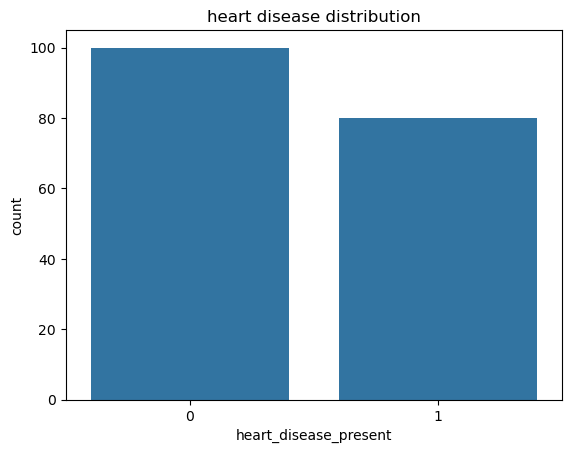

In [105]:
sns.countplot(x="heart_disease_present",data=df)
plt.title("heart disease distribution")
plt.show()

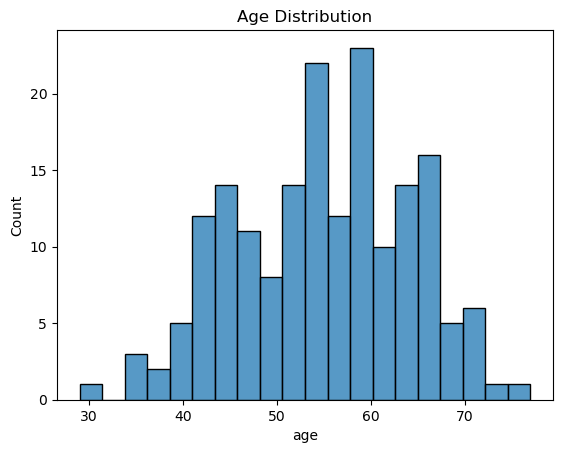

In [106]:
sns.histplot(df["age"],bins=20)
plt.title("Age Distribution")
plt.show()

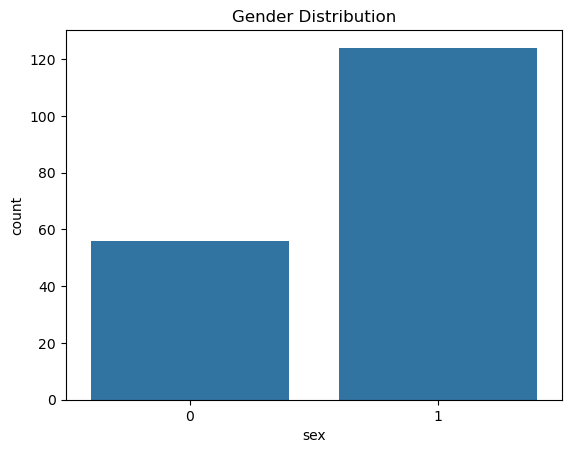

In [107]:
sns.countplot(x='sex', data=df)
plt.title("Gender Distribution")
plt.show()

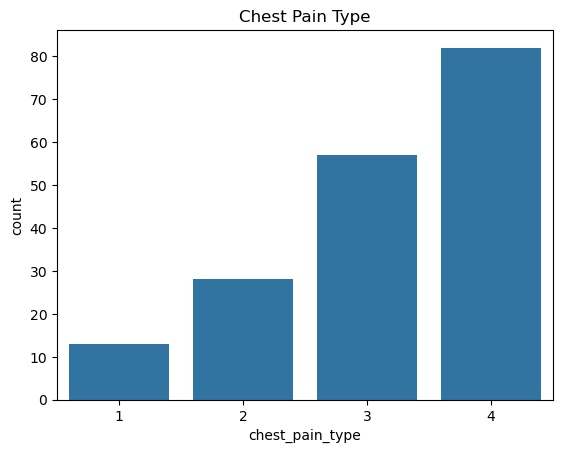

In [108]:
sns.countplot(x='chest_pain_type', data=df)
plt.title("Chest Pain Type")
plt.show()

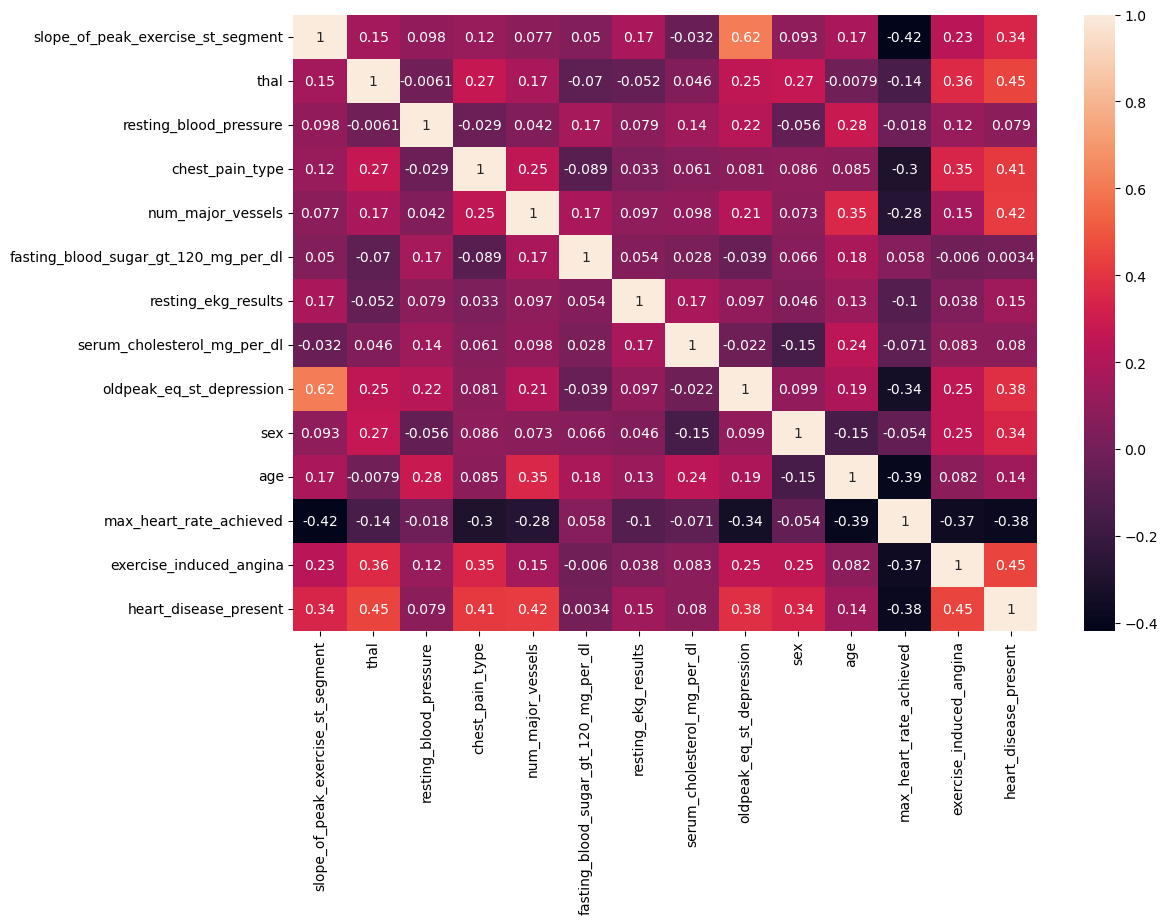

In [109]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [110]:
df.dtypes

slope_of_peak_exercise_st_segment         int64
thal                                      int64
resting_blood_pressure                    int64
chest_pain_type                           int64
num_major_vessels                         int64
fasting_blood_sugar_gt_120_mg_per_dl      int64
resting_ekg_results                       int64
serum_cholesterol_mg_per_dl               int64
oldpeak_eq_st_depression                float64
sex                                       int64
age                                       int64
max_heart_rate_achieved                   int64
exercise_induced_angina                   int64
heart_disease_present                     int64
dtype: object

In [111]:
X = df.drop('heart_disease_present', axis=1)
y = df['heart_disease_present']

In [112]:
from sklearn.model_selection import train_test_split

In [113]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42)
    

In [114]:
from sklearn.linear_model import LogisticRegression

In [115]:
model=LogisticRegression()

In [116]:
lr = LogisticRegression(max_iter=1000)

In [117]:
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [118]:
y_pred_lr = lr.predict(X_test)

In [119]:
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8055555555555556


In [120]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.7777777777777778


In [121]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8055555555555556


In [122]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.5277777777777778


In [123]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        knn_accuracy
    ]
})
comparison

,Model,Accuracy
0,Logistic Regression,0.805556
1,Decision Tree,0.777778
2,Random Forest,0.805556
3,KNN,0.527778


In [124]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_rf)
print(cm)

[[15  1]
 [ 6 14]]


In [125]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.71      0.94      0.81        16
           1       0.93      0.70      0.80        20

    accuracy                           0.81        36
   macro avg       0.82      0.82      0.81        36
weighted avg       0.84      0.81      0.80        36



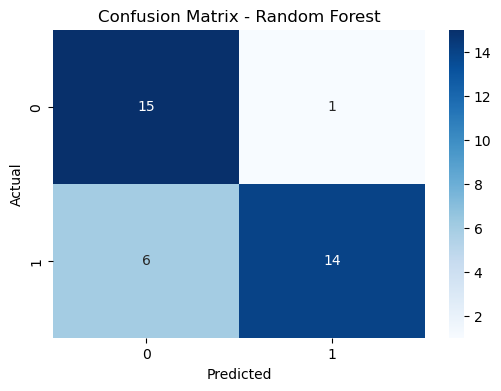

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

# Model Comparison Report

Four machine learning classification algorithms were trained and evaluated to predict the presence of heart disease.

Model  Accuracy:
Logistic Regression = 80.56%
Decision Tree = 77.78% 
Random Forest =  80.56% 
K-Nearest Neighbors (KNN) = 52.78% 

Among the four algorithms, Logistic Regression and Random Forest achieved the highest accuracy of 80.56%. Decision Tree also performed reasonably well with an accuracy of 77.78%, whereas KNN produced the lowest accuracy of 52.78%.

Based on the evaluation results, Random Forest is selected as the final model because it provides high predictive performance and is generally robust to noise and overfitting.

# Model Evaluation Report

The Random Forest model was evaluated using a confusion matrix and classification report.

Confusion Matrix:

[[15 1]
 [6 14]]

The model correctly classified 15 patients without heart disease and 14 patients with heart disease.

Only one healthy patient was incorrectly predicted as having heart disease, while six patients with heart disease were incorrectly predicted as healthy.

The classification report shows:

• Accuracy : 80.56%
• Precision : 93% for patients with heart disease.
• Recall : 70% for patients with heart disease.
• F1-score : 80%.

These results indicate that the Random Forest model provides reliable performance for predicting heart disease.

# Suggestions to the Hospital

1. should conduct regular cardiovascular screening for high-risk patients.

2. Encourage healthy dietary habits and regular physical exercise.

3. Monitor blood pressure, cholesterol levels, and blood sugar regularly.

4. Increase awareness regarding smoking cessation and stress management.

5. Use machine learning models as a decision-support tool for early detection of heart disease.

6. Schedule regular follow-up examinations for patients identified as high risk.

# Conclusion

In this project, a heart disease prediction system was developed using machine learning techniques. The dataset was cleaned, preprocessed, explored through data analysis, and used to train four classification algorithms.

Among all the models, Logistic Regression and Random Forest achieved the highest accuracy of 80.56%. Based on its overall performance and robustness, Random Forest was selected as the final prediction model.

This project demonstrates that machine learning can assist healthcare professionals in the early detection of heart disease, enabling timely medical intervention and potentially improving patient outcomes.